# Late-onset baseline consensus review

Interactive notebook for testing `per_camera_gp_baseline_masked` with the refined
late-onset consensus logic.

**Baseline comparison labels:**
- **Consensus ON** — full refined logic (`late_onset_buffer_days=100`, anchor consensus for cameras that start during excursions)
- **Consensus OFF** — same GP masking, but late-onset consensus disabled (`late_onset_buffer_days=0`)

Use this notebook to:
- Inspect per-band anchor / needs-consensus classification
- Compare baselines with consensus ON vs OFF
- Visualize per-camera and whole-lightcurve baseline performance

Known regression target: source `223338997633` (`cB` should need consensus;
`bn`/`bF`/`bB` should remain unchanged).

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()

def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists() and (p / "malca").is_dir():
            return p
    return start

REPO_ROOT = find_repo_root(HERE)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.baseline import (
    _classify_band_cameras,
    _compute_base_rough,
    _mask_excursions,
    _quiet_span_before_first_excursion,
    per_camera_gp_baseline_masked,
)
from malca.config import (
    BASELINE_S0,
    BASELINE_Q,
    GP_CONSENSUS_START_RESID_SIGMA,
    GP_LATE_ONSET_BUFFER_DAYS,
    GP_MIN_ANCHOR_OVERLAP_DAYS,
    GP_MIN_QUIET_BASELINE_DAYS,
)
from malca.stv.events import DEFAULT_BASELINE_KWARGS
from malca.utils import read_lc_dat2

print("Repo:", REPO_ROOT)

Repo: /Users/calder/code/malca


In [10]:
# ---- User configuration ----
ASASSN_ID = "223338997633"

LC_SEARCH_DIRS = [
    REPO_ROOT / "output_migrated_camera_field_20260606/runs/runs_march18_bundle_all/bundle_assets/lightcurves",
    REPO_ROOT / "output/runs/runs_march18_bundle_all/bundle_assets/lightcurves",
]

JD_OFFSET = 2458000.0  # plot x-axis as JD - JD_OFFSET

BASELINE_KWARGS = {
    **DEFAULT_BASELINE_KWARGS,
    "late_onset_buffer_days": GP_LATE_ONSET_BUFFER_DAYS,
    "min_anchor_overlap_days": GP_MIN_ANCHOR_OVERLAP_DAYS,
    "min_quiet_baseline_days": GP_MIN_QUIET_BASELINE_DAYS,
    "consensus_start_resid_sigma": GP_CONSENSUS_START_RESID_SIGMA,
}

print("Baseline kwargs:", BASELINE_KWARGS)

Baseline kwargs: {'S0': 0.0005, 'w0': 0.0031415926535897933, 'q': 0.7, 'jitter': 0.006, 'sigma_floor': None, 'add_sigma_eff_col': True, 'late_onset_buffer_days': 100.0, 'min_anchor_overlap_days': 30.0, 'min_quiet_baseline_days': 250.0, 'consensus_start_resid_sigma': 3.0}


In [11]:
def find_lc_dir(asassn_id: str) -> Path:
    for d in LC_SEARCH_DIRS:
        if (d / f"{asassn_id}.dat3").exists():
            return d
    raise FileNotFoundError(f"No lightcurve for {asassn_id} in {LC_SEARCH_DIRS}")


def load_lc(asassn_id: str) -> pd.DataFrame:
    lc_dir = find_lc_dir(asassn_id)
    dfg, dfv = read_lc_dat2(asassn_id, str(lc_dir), file_ext="dat3")
    df = pd.concat([dfg, dfv], ignore_index=True)
    return df.sort_values("JD").reset_index(drop=True)


def diagnose_bands(df: pd.DataFrame, *, band_col="v_g_band", cam_col="camera#") -> pd.DataFrame:
    """Run Pass-1 helpers and band classification; return per-camera summary."""
    cam_meta = {}
    anchor_base_rough = {}
    cam_band_map = {}
    name_by_cam = {}

    for cam_id, sub in df.groupby(cam_col):
        sub = sub.sort_values("JD")
        t = sub["JD"].to_numpy(float)
        mag = sub["mag"].to_numpy(float)
        err = sub["error"].to_numpy(float)
        finite = np.isfinite(t) & np.isfinite(mag)
        med = float(np.nanmedian(mag[finite]))
        br = _compute_base_rough(
            t, mag, err, finite, med,
            auto_scale_gp=True, min_gp_points=10,
            stiff_scale_fraction=2.0, stiff_min_days=1000.0,
            S0=BASELINE_S0, q=BASELINE_Q,
        )
        _f, _k, intervals, s0 = _mask_excursions(
            t, mag, br, finite, med, mag_err=err,
            dip_sigma_thresh=3.0, bright_sigma_thresh=-3.0, pad_days=5.0,
        )
        t_first = float(t[finite].min())
        t_last = float(t[finite].max())
        name = sub["camera_name"].iloc[0] if "camera_name" in sub.columns else str(cam_id)
        name_by_cam[cam_id] = name
        cam_band_map[cam_id] = sub[band_col].iloc[0]
        cam_meta[cam_id] = {
            "t_first": t_first,
            "t_last": t_last,
            "quiet_span": _quiet_span_before_first_excursion(t_first, t_last, intervals),
            "excursion_intervals": intervals,
            "mask_s0": s0,
            "mag_at_first": float(mag[finite][0]),
        }
        anchor_base_rough[cam_id] = (t, br)

    rows = []
    for band_id, band_sub in df.groupby(band_col):
        band_cam_ids = list(band_sub[cam_col].unique())
        band_start = min(cam_meta[c]["t_first"] for c in band_cam_ids)
        anchors, needs = _classify_band_cameras(
            band_cam_ids, cam_meta, anchor_base_rough, cam_band_map, band_id,
            late_onset_buffer_days=BASELINE_KWARGS["late_onset_buffer_days"],
            min_quiet_baseline_days=BASELINE_KWARGS["min_quiet_baseline_days"],
            min_anchor_overlap_days=BASELINE_KWARGS["min_anchor_overlap_days"],
            consensus_start_resid_sigma=BASELINE_KWARGS["consensus_start_resid_sigma"],
        )
        for cam_id in band_cam_ids:
            meta = cam_meta[cam_id]
            rows.append({
                "band": band_id,
                "camera#": cam_id,
                "camera_name": name_by_cam[cam_id],
                "jd_first": meta["t_first"],
                "jd_last": meta["t_last"],
                "delay_vs_band_start": meta["t_first"] - band_start,
                "quiet_span_own_d": meta["quiet_span"],
                "n_excursion_intervals": len(meta["excursion_intervals"]),
                "is_anchor": cam_id in anchors,
                "needs_consensus": cam_id in needs,
            })
    return pd.DataFrame(rows).sort_values(["band", "jd_first"]).reset_index(drop=True)


def fit_baseline_comparison(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run masked GP baseline with consensus ON and OFF."""
    result_on = per_camera_gp_baseline_masked(df, **BASELINE_KWARGS)
    result_off = per_camera_gp_baseline_masked(
        df,
        late_onset_buffer_days=0,
        **{k: v for k, v in BASELINE_KWARGS.items() if k != "late_onset_buffer_days"},
    )
    return result_on, result_off


def compare_baselines(df: pd.DataFrame) -> pd.DataFrame:
    on, off = fit_baseline_comparison(df)
    cam_name = df.groupby("camera#")["camera_name"].first() if "camera_name" in df.columns else None

    rows = []
    for cam_id in df["camera#"].unique():
        m = on["camera#"] == cam_id
        diff = np.abs(on.loc[m, "baseline"].to_numpy(float) - off.loc[m, "baseline"].to_numpy(float))
        rows.append({
            "camera#": cam_id,
            "camera_name": cam_name[cam_id] if cam_name is not None else cam_id,
            "max_baseline_diff": float(np.nanmax(diff)) if diff.size else np.nan,
            "max_base_rough_diff": float(np.nanmax(np.abs(
                on.loc[m, "base_rough"].to_numpy(float) - off.loc[m, "base_rough"].to_numpy(float)
            ))) if diff.size else np.nan,
        })
    return pd.DataFrame(rows).sort_values("max_baseline_diff", ascending=False)

In [12]:
df = load_lc(ASASSN_ID)
print(f"Loaded {ASASSN_ID}: {len(df)} points, {df['camera#'].nunique()} cameras")
display(df.groupby(["v_g_band", "camera_name"]).agg(n=("JD", "size"), jd_min=("JD", "min"), jd_max=("JD", "max")))

Loaded 223338997633: 1379 points, 8 cameras


n       jd_min       jd_max
v_g_band camera_name                               
0        bB           118   8455.75021   9614.70983
         bF           165   8392.69624  11026.55203
         bj           189   8013.80188  11025.66317
         bn           258   8128.34066  11048.34443
         br           193   8018.84412  11090.57947
         cB           178  10111.10155  11075.71974
1        bb           222   6658.77301   8451.83145
         bf            56   7630.88997   8379.66308

In [13]:
            diag = diagnose_bands(df)
display(diag)

cmp = compare_baselines(df)
print("\nBaseline diff (consensus ON vs late_onset_buffer_days=0):")
display(cmp)

,band,camera#,camera_name,jd_first,jd_last,delay_vs_band_start,quiet_span_own_d,n_excursion_intervals,is_anchor,needs_consensus
0,0,3,bj,8013.80188,11025.66317,0.00000,784.83029,13,True,False
1,0,4,br,8018.84412,11090.57947,5.04224,2502.06058,7,True,False
2,0,5,bn,8128.34066,11048.34443,114.53878,2360.25569,11,True,False
3,0,6,bF,8392.69624,11026.55203,378.89436,774.89267,14,True,False
4,0,7,bB,8455.75021,9614.70983,441.94833,1158.95962,0,True,False
5,0,8,cB,10111.10155,11075.71974,2097.29967,964.61819,0,False,True
6,1,1,bb,6658.77301,8451.83145,0.00000,1793.05844,0,True,False
7,1,2,bf,7630.88997,8379.66308,972.11696,748.77311,0,True,False



Baseline diff (consensus ON vs late_onset_buffer_days=0):


,camera#,camera_name,max_baseline_diff,max_base_rough_diff
7,8,cB,0.14215,0.09239
0,1,bb,0.00000,0.00000
1,2,bf,0.00000,0.00000
2,3,bj,0.00000,0.00000
3,4,br,0.00000,0.00000
4,5,bn,0.00000,0.00000
5,6,bF,0.00000,0.00000
6,7,bB,0.00000,0.00000


In [14]:
from matplotlib.lines import Line2D


def _style_mag_axis(ax, ylabel: str, *, invert: bool = True) -> None:
    """Apply astronomical magnitude axis convention (brighter / smaller values up)."""
    ax.set_ylabel(ylabel)
    if invert:
        ax.invert_yaxis()


def plot_baseline_review(
    df: pd.DataFrame,
    *,
    cameras: list[str] | None = None,
    compare_off: bool = True,
    jd_offset: float = JD_OFFSET,
    result_on: pd.DataFrame | None = None,
    result_off: pd.DataFrame | None = None,
):
    """Two-row panel per camera: mag + base_rough/baseline; residuals."""
    if result_on is None or (compare_off and result_off is None):
        result_on, result_off = fit_baseline_comparison(df)
    elif not compare_off:
        result_off = None

    if cameras is None:
        cameras = sorted(df["camera_name"].unique()) if "camera_name" in df.columns else sorted(df["camera#"].unique())

    cam_col = "camera_name" if "camera_name" in df.columns else "camera#"

    for cam in cameras:
        sub_on = result_on[result_on[cam_col] == cam].sort_values("JD")
        if sub_on.empty:
            continue
        t = sub_on["JD"].to_numpy(float) - jd_offset
        mag = sub_on["mag"].to_numpy(float)

        fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
        ax0, ax1 = axes

        ax0.scatter(t, mag, s=8, alpha=0.6, label="data", color="0.3")
        ax0.plot(t, sub_on["base_rough"], color="tab:orange", lw=1.2, alpha=0.9, label="base_rough (consensus ON)")
        ax0.plot(t, sub_on["baseline"], color="tab:blue", lw=1.5, label="baseline (consensus ON)")

        if result_off is not None:
            sub_off = result_off[result_off[cam_col] == cam].sort_values("JD")
            t_off = sub_off["JD"].to_numpy(float) - jd_offset
            ax0.plot(
                t_off, sub_off["baseline"], color="tab:red", lw=1.0, ls="--", alpha=0.8,
                label="baseline (consensus OFF)",
            )
            ax1.plot(
                t, sub_on["resid"] - sub_off["resid"].to_numpy(float),
                color="tab:purple", lw=1.0, label="resid(ON) − resid(OFF)",
            )

        _style_mag_axis(ax0, "Magnitude [mag]")
        ax0.legend(loc="best", fontsize=8)
        ax0.set_title(f"{ASASSN_ID} / {cam}")

        ax1.axhline(0, color="0.5", lw=0.8)
        ax1.scatter(t, sub_on["resid"], s=8, alpha=0.6, color="0.3", label="resid (consensus ON)")
        _style_mag_axis(ax1, "Residual [mag]")
        ax1.set_xlabel(f"JD - {jd_offset:.0f}")
        ax1.legend(loc="best", fontsize=8)

        plt.show()


def plot_whole_lightcurve_review(
    df: pd.DataFrame,
    *,
    compare_off: bool = True,
    jd_offset: float = JD_OFFSET,
    result_on: pd.DataFrame | None = None,
    result_off: pd.DataFrame | None = None,
):
    """All cameras on shared axes for overall baseline assessment."""
    if result_on is None or (compare_off and result_off is None):
        result_on, result_off = fit_baseline_comparison(df)
    elif not compare_off:
        result_off = None

    cam_col = "camera_name" if "camera_name" in df.columns else "camera#"
    cameras = sorted(result_on[cam_col].unique())
    cmap = plt.cm.tab10

    nrows = 3 if compare_off else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 3.2 * nrows), sharex=True, constrained_layout=True)
    ax0, ax1 = axes[0], axes[1]
    ax2 = axes[2] if compare_off else None

    for i, cam in enumerate(cameras):
        color = cmap(i % 10)
        sub_on = result_on[result_on[cam_col] == cam].sort_values("JD")
        t = sub_on["JD"].to_numpy(float) - jd_offset
        mag = sub_on["mag"].to_numpy(float)
        marker = "s" if "v_g_band" in sub_on.columns and sub_on["v_g_band"].iloc[0] == 1 else "o"

        ax0.scatter(t, mag, s=12, alpha=0.45, color=color, marker=marker)
        ax0.plot(t, sub_on["baseline"], color=color, lw=1.2, alpha=0.9, label=cam)

        if result_off is not None:
            sub_off = result_off[result_off[cam_col] == cam].sort_values("JD")
            t_off = sub_off["JD"].to_numpy(float) - jd_offset
            ax0.plot(t_off, sub_off["baseline"], color=color, lw=0.9, ls="--", alpha=0.5)

        ax1.scatter(t, sub_on["resid"], s=12, alpha=0.45, color=color, marker=marker, label=cam)

        if ax2 is not None:
            resid_diff = sub_on["resid"].to_numpy(float) - sub_off["resid"].to_numpy(float)
            ax2.plot(t, resid_diff, color=color, lw=1.0, alpha=0.85, label=cam)

    baseline_legend = [
        Line2D([0], [0], color="k", lw=1.2, label="baseline (consensus ON)"),
    ]
    if compare_off:
        baseline_legend.append(
            Line2D([0], [0], color="k", lw=1.0, ls="--", alpha=0.5, label="baseline (consensus OFF)")
        )

    _style_mag_axis(ax0, "Magnitude [mag]")
    ax0.set_title(f"{ASASSN_ID} — whole lightcurve (all cameras)")
    handles, labels = ax0.get_legend_handles_labels()
    extra_labels = [h.get_label() for h in baseline_legend]
    ax0.legend(
        handles=handles + baseline_legend,
        labels=labels + extra_labels,
        loc="upper right",
        fontsize=7,
        ncol=3,
    )

    ax1.axhline(0, color="0.5", lw=0.8)
    _style_mag_axis(ax1, "Residual [mag]")
    ax1.legend(loc="upper right", fontsize=7, ncol=4)

    if ax2 is not None:
        ax2.axhline(0, color="0.5", lw=0.8)
        _style_mag_axis(ax2, "Δ residual [mag]")
        ax2.set_xlabel(f"JD - {jd_offset:.0f}")
        ax2.legend(loc="upper right", fontsize=7, ncol=4)
    else:
        ax1.set_xlabel(f"JD - {jd_offset:.0f}")

    plt.show()

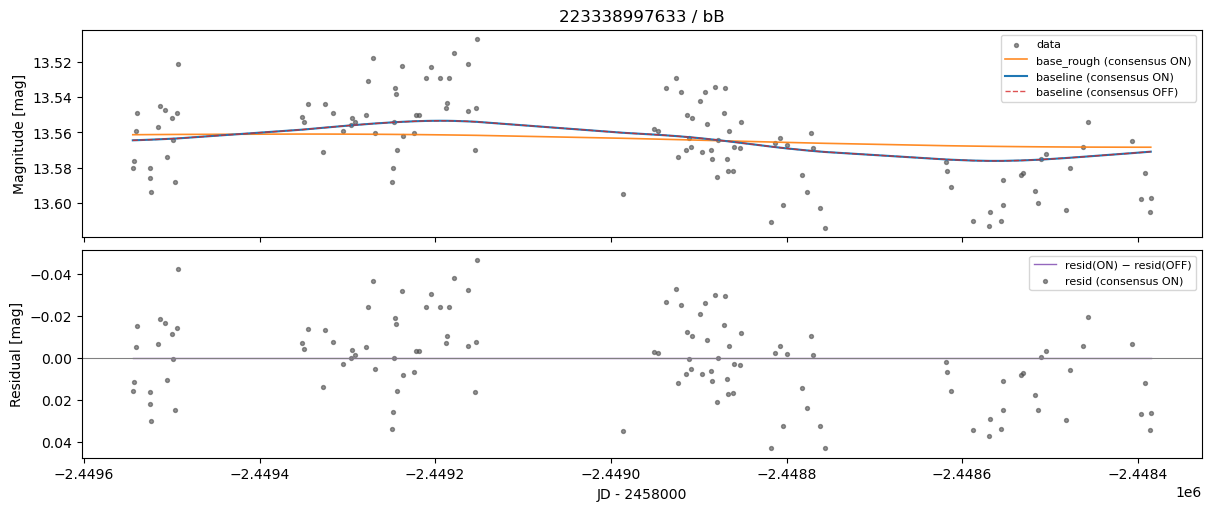

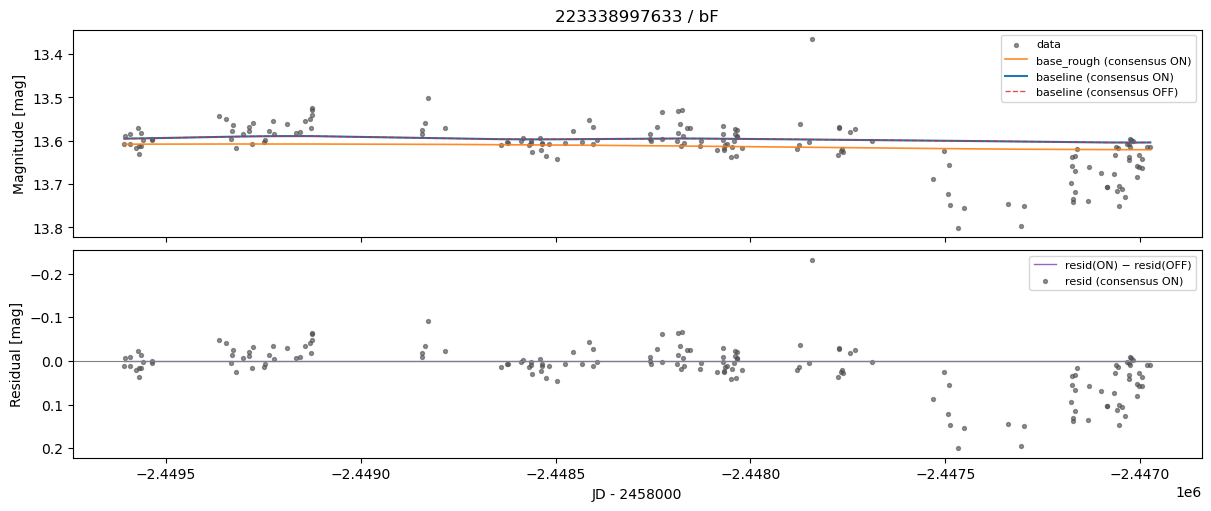

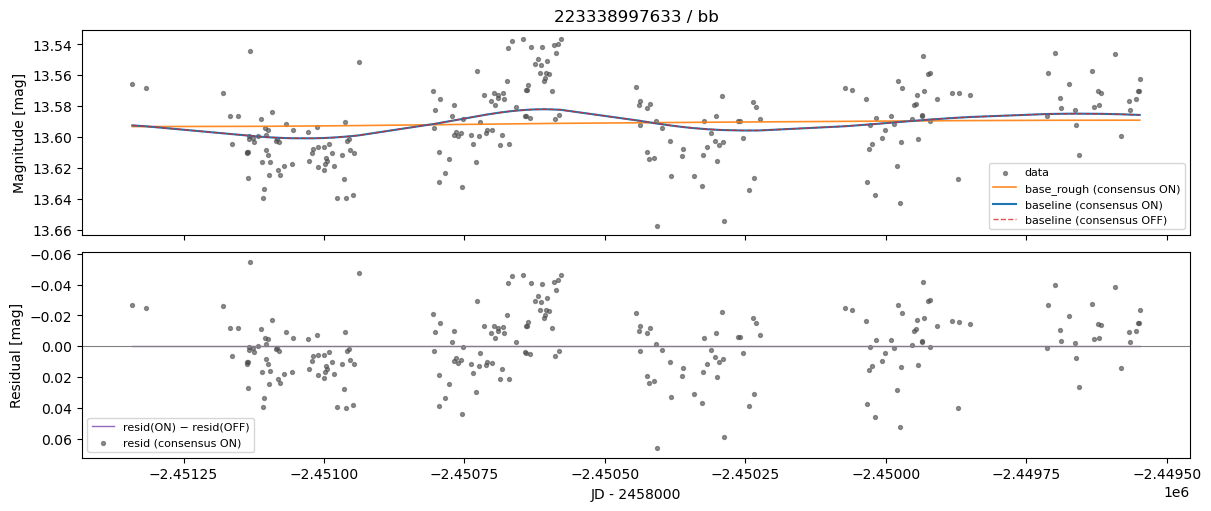

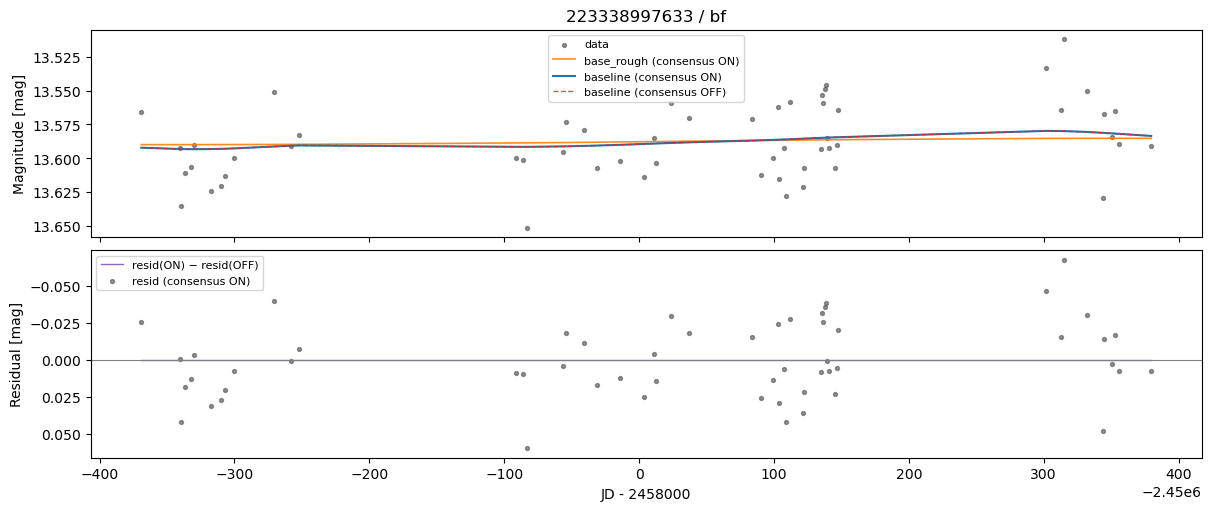

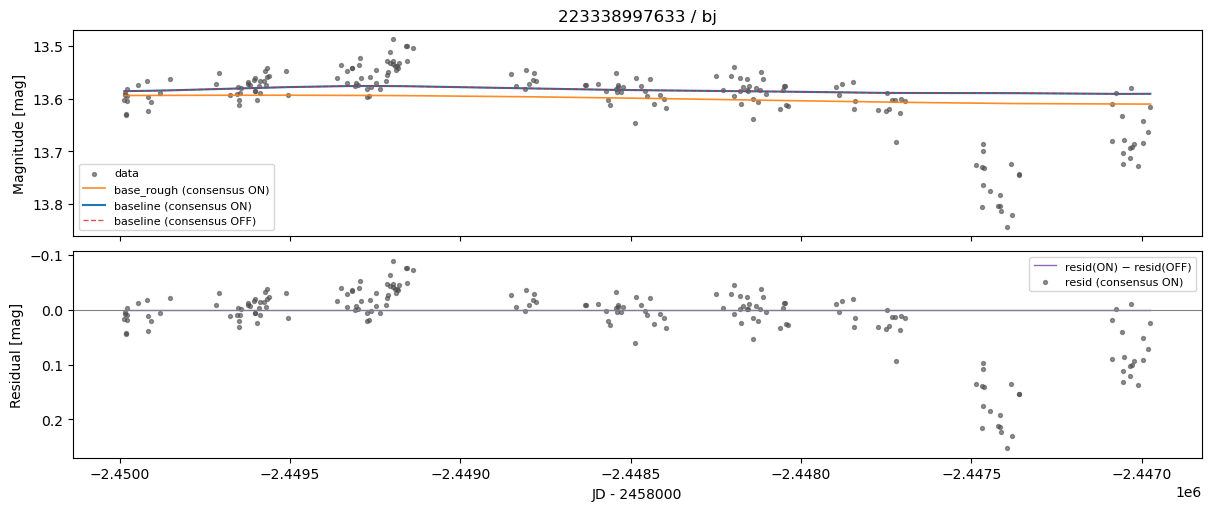

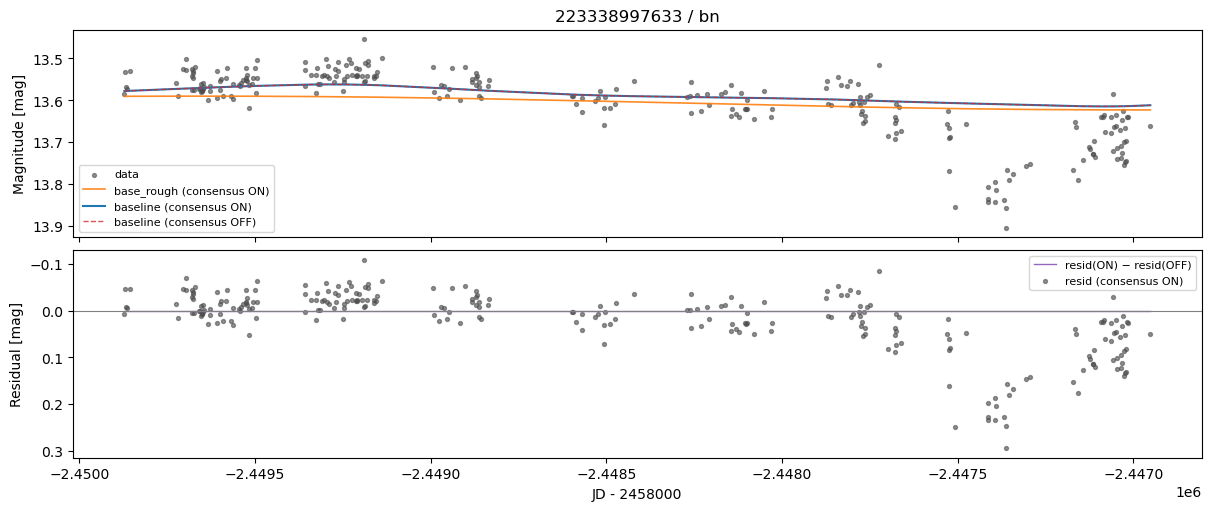

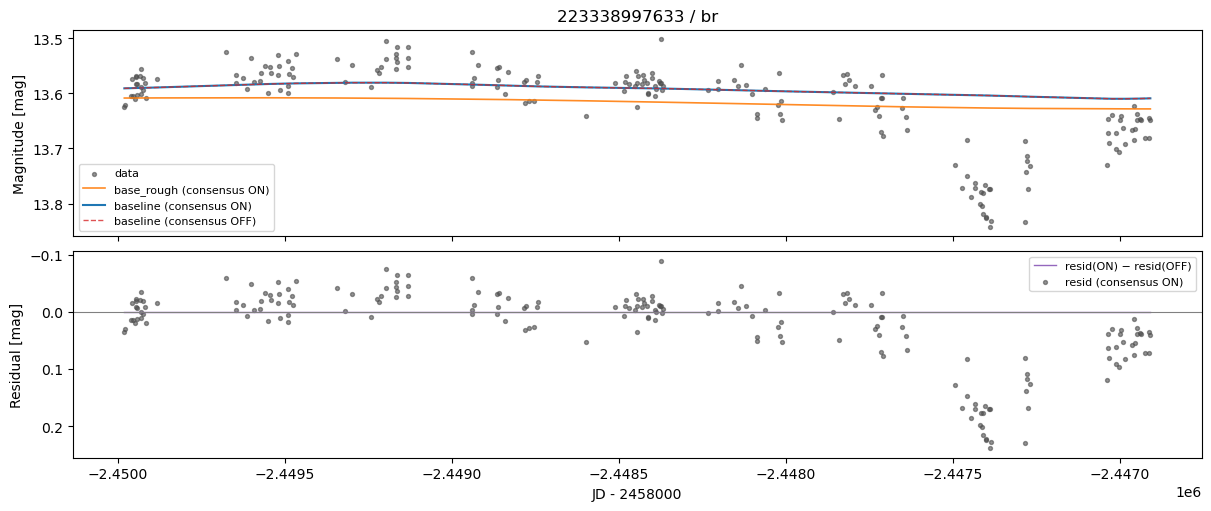

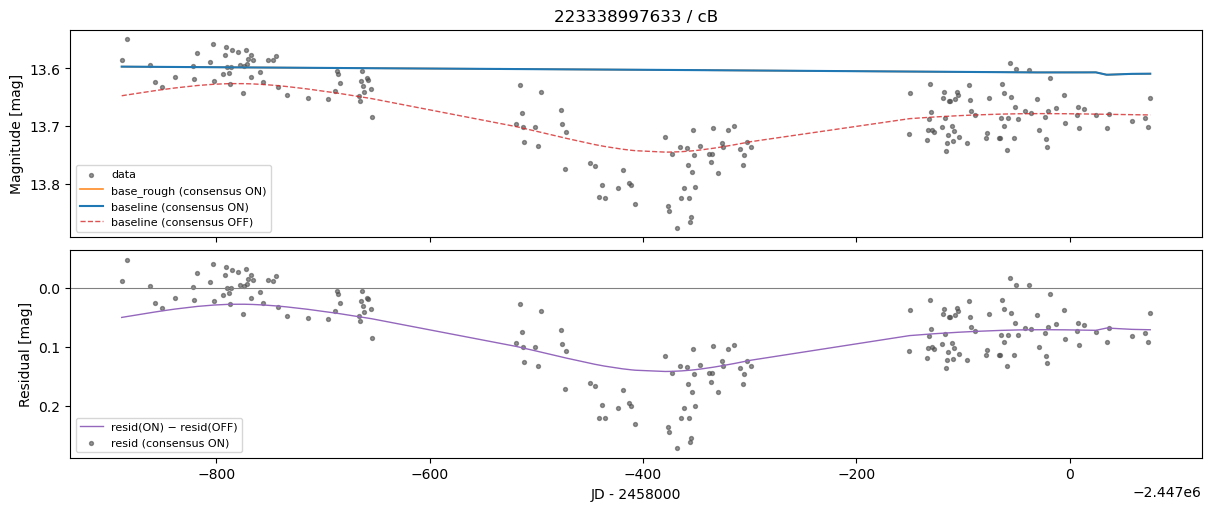

In [15]:
# Fit once so per-camera and whole-LC plots share the same baseline runs
result_on, result_off = fit_baseline_comparison(df)

# Per-camera panels (set cameras=["cB"] to focus on the late-onset case)
plot_baseline_review(df, cameras=None, compare_off=True, result_on=result_on, result_off=result_off)

## Whole lightcurve overview

All cameras overlaid on shared axes — useful for judging overall baseline quality and
where consensus ON vs OFF diverges (third panel).

TypeError: A single argument passed to legend() must be a list of labels, but found an Artist in there.

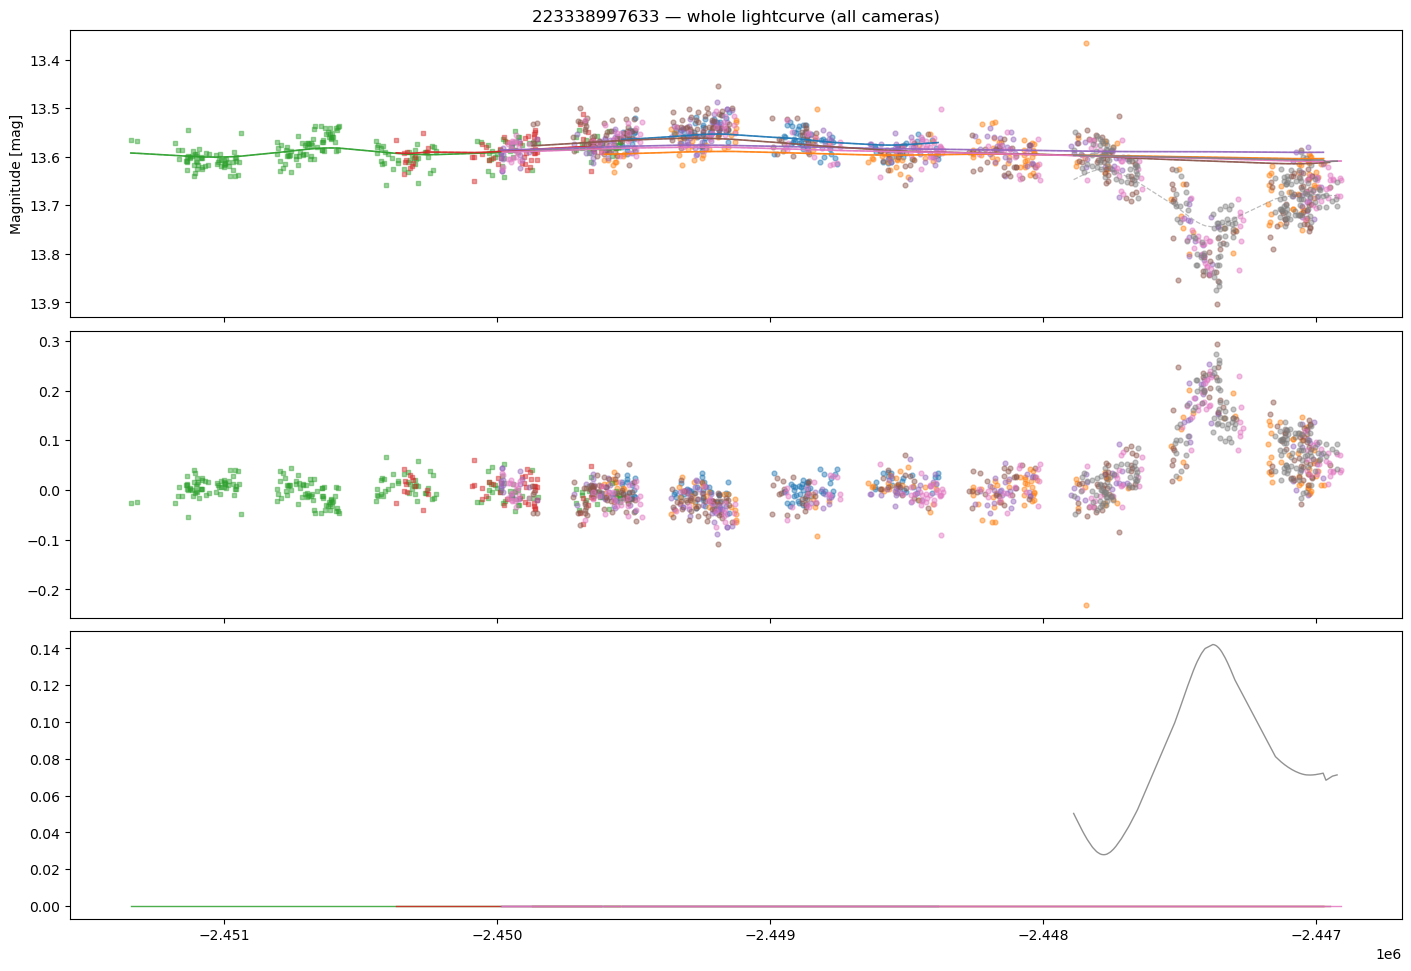

In [16]:
plot_whole_lightcurve_review(
    df,
    compare_off=True,
    result_on=result_on,
    result_off=result_off,
)

## Synthetic staggered rollout

Mirrors unit-test geometry: `bj`/`bn`/`bF` have long quiet baselines; only `cB`
starts near the dip and should receive consensus `base_rough`.

In [ ]:
from tests.test_baseline import _make_staggered_rollout_lc

syn = _make_staggered_rollout_lc()
display(diagnose_bands(syn))
display(compare_baselines(syn))
plot_baseline_review(syn, cameras=["cB"], compare_off=True)